In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def cv_show(img,name):
    cv2.imshow(name,img)
    cv2.waitKey()
    cv2.destroyAllWindows()

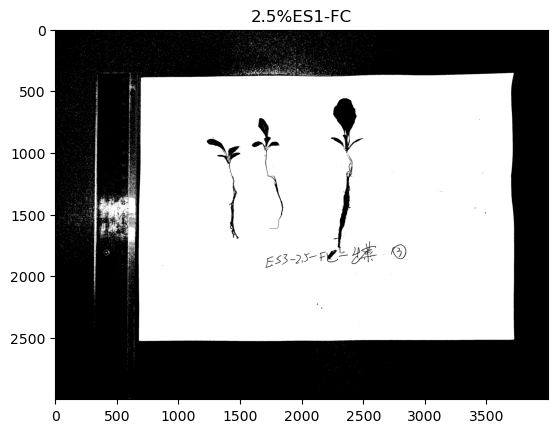

In [3]:
# binary
img = cv2.imread('GHPicture_2.5%ES/2.5%ES3-FC.jpg')
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret,thresh = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)
plt.subplot(111), plt.imshow(thresh,'gray'), plt.title('2.5%ES1-FC');

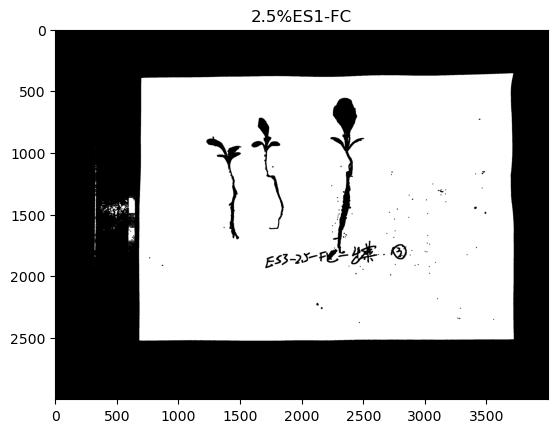

In [4]:
kernel = np.ones((3,3),np.uint8) #创建卷积核
erosion_3 = cv2.erode(thresh,kernel,iterations = 3)
plt.subplot(111), plt.imshow(erosion_3,'gray'), plt.title('2.5%ES1-FC');

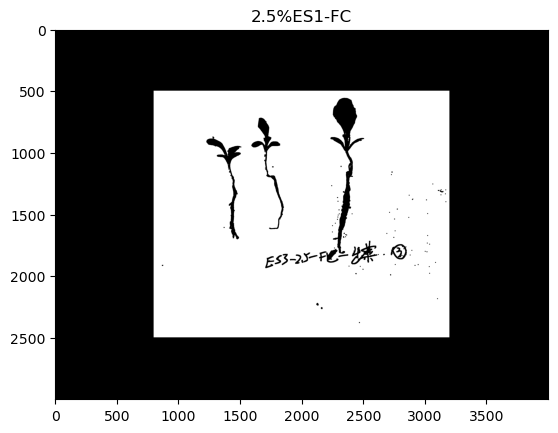

In [5]:
# 创建mask
mask = np.zeros(img.shape[:2], np.uint8)
h,w = img.shape[:2]
d_h = int(h/6)
d_w = int(w/5)
mask[d_h:h-d_h, d_w:w-d_w] = 255
masked_erosion_3 = cv2.bitwise_and(erosion_3, erosion_3, mask=mask)#与操作
plt.subplot(111), plt.imshow(masked_erosion_3,'gray'), plt.title('2.5%ES1-FC');

In [6]:
contours, hierarchy = cv2.findContours(masked_erosion_3, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)

90 36890.5
94 33470.0
98 85738.5


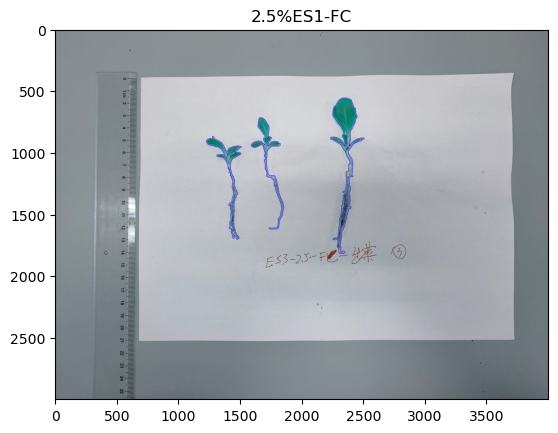

In [7]:
draw_img = img.copy()
root_contour_n = []
for i in range(len(contours)):
    cnt = contours[i]
    if cv2.contourArea(cnt)>20000 and cv2.contourArea(cnt)< 200000:
        res = cv2.drawContours(draw_img, contours, i, (0, 0, 255), 2)
        print(i,cv2.contourArea(cnt))
        root_contour_n.append(i)
plt.subplot(111), plt.imshow(res), plt.title('2.5%ES1-FC');

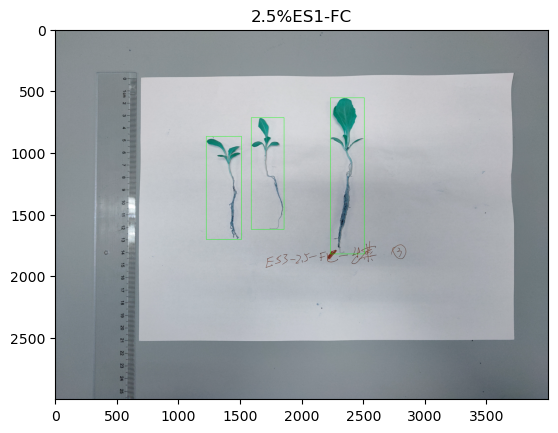

In [8]:
draw_img = img.copy()
plant = []
for i in root_contour_n:
    x,y,w,h = cv2.boundingRect(contours[i])
    res = cv2.rectangle(draw_img,(x,y),(x+w,y+h),(0,255,0),2)
    plant.append((x,y,w,h))
plt.subplot(111), plt.imshow(res), plt.title('2.5%ES1-FC');

306
290
437


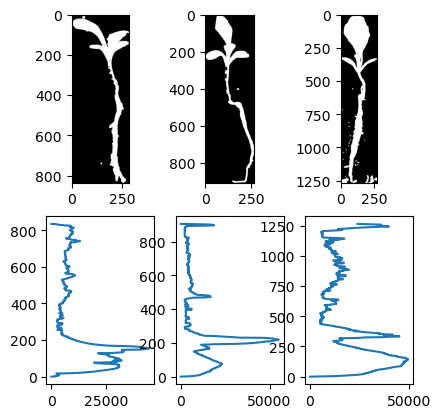

In [9]:
plant_img_set = []
root_position = []
for i in range(len(plant)):
    x,y,w,h = plant[i]
    plant_img = 255-masked_erosion_3[y:y+h,x:x+w]
    plant_img_set.append(plant_img)
    sum_x = []
    set_y = []
    for j in range(h):
        integral_x = sum(plant_img[j,0:w])
        sum_x.append(integral_x)
        set_y.append(j)
    ssum_x = sum_x[int(h/5):int(h*4/5)]
    min_id = sorted(range(len(ssum_x)), key = lambda k : ssum_x[k])[0]+int(h/5)
    root_position.append(min_id)
    print(min_id)
    plt.subplot(241+i), plt.imshow(plant_img,'gray');
    plt.subplot(245+i), plt.plot(sum_x,set_y,)   

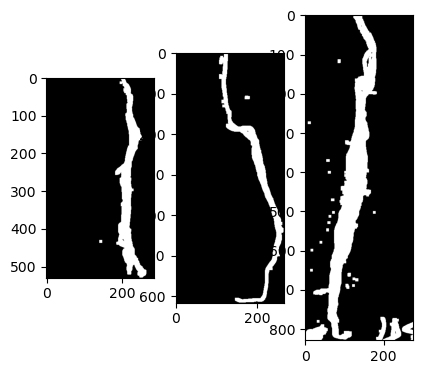

In [10]:
root_image = []
for i in range(len(plant_img_set)):
    y = root_position[i]
    plant_img = plant_img_set[i]
    h,w = plant_img.shape[:2]
    root_img = plant_img[y:h,0:w]
    root_image.append(root_img)
    plt.subplot(141+i), plt.imshow(root_img,'gray');

In [11]:
def root_cnt(img):
    contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
    for i in range(len(contours)):
        cnt = contours[i]
        if cv2.contourArea(cnt)>2000:
            draw_img = img.copy()
            res = cv2.drawContours(draw_img, contours, i, (0, 0, 255), 2)
            print(i)
            return cnt

1
1
24


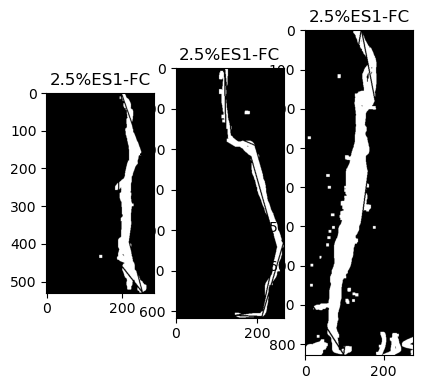

In [12]:
root_pix = []
for i in range(len(root_image)):
    img_root = root_image[i]
    draw_img = img_root.copy()
    cnt = root_cnt(img_root)
    epsilon = 0.02*cv2.arcLength(cnt,True)
    approx = cv2.approxPolyDP(cnt,epsilon,True)
    res = cv2.drawContours(draw_img, [approx], -1, (0, 0, 255), 2)
    root_pix.append(cv2.arcLength(approx,True))
    plt.subplot(141+i), plt.imshow(res,'gray'), plt.title('2.5%ES1-FC');

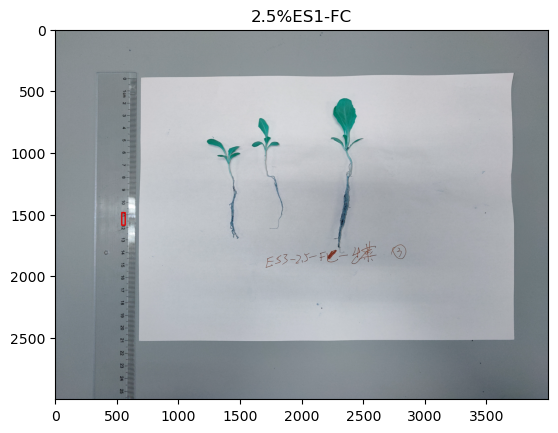

In [13]:
# match ruler
p_12 = []
for i in range(11,13):
    temple = cv2.imread(f'GHPicture_2.5%ES/ruler_{i}.png')
    temple_gray = cv2.cvtColor(temple,cv2.COLOR_BGR2GRAY)
    res = cv2.matchTemplate(gray,temple_gray,1)
    min_val,max_val,min_loc,max_loc = cv2.minMaxLoc(res)
    p_12.append(min_loc)
h,w = temple.shape[:2]
h = p_12[1][1]-p_12[0][1]

top_left = p_12[0]
bottom_right = (top_left[0]+w,top_left[1]+h)

img2 = img.copy()
cv2.rectangle(img2, top_left, bottom_right, 225, 10)
plt.subplot(111), plt.imshow(img2), plt.title('2.5%ES1-FC');

In [14]:
# h = 1cm
root_length = []
for i in root_pix:
    root_len = i/2/h
    root_length.append(root_len)
    print(root_len)

5.374104443718405
7.098178302540498
8.314837511848001


In [15]:
np.average(root_length)

6.929040086035634